# KNN Imputer
KNN Imputer is a data imputation technique that fills values by finding the k-nearest neighbors of each sample with missing values and averaging their values for the missing feature(s). It's a sophisticated alternative to mean/median imputation that preserves data relationships

---
## The Core Concept
**How it works:**  
1. For each sample with missing values, find k samples (neighbors) that are most similar
2. Use the values of these neighbors to estimate the missing values
3. Typically, the mean (or weighted mean) of neighbors' values is used
---
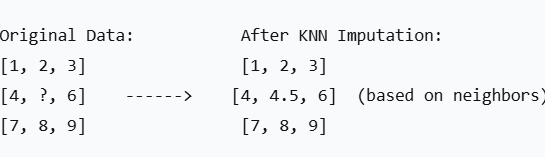

---
## Mathematical Foundation
**Distance Metric** (typically Euclidean)  
`d(x, y) = √(Σ(xi - yi)²)`

## Imputation Value (weighted average)
`x_missing = (Σ w_i * x_i) / Σ w_i` ; where w_i = 1/d(x, x_i) (inverse distance weighting)

---
## Key Parameters
|Parameter|Description|Typical Values|
|---------|-----------|--------------|
|**n_neighbors**|Number of neighbors to consider|3, 7, 5|
|**weights**|Weight function for neighbors|'uniform', 'distance'|
|**metric**|Distance metric|'euclidean', 'manhattan'|
|**copy**|Whether to copy the data|True/False|

---

## Advantages & Disadvantages
|Pros|Cons|
|----|----|
|✅Preserves data relationships and structure|❌Computationally expensive for large datasets|
|✅Can handle multiple missing features simultaneously|❌Sensitive to scale (requires normalization)|
|✅More accurate than mean/median imputation|❌Struggles with high-dimensional data (curse of dimensionality)|
|✅Works well with both numerical and categorical|❌Can be biased if missing pattern is not random|

---
## When to Use KNN Imputation
**Best for**:
* Datasets with moderate size (< 100k rows)
* Numerical features with `MAR/MCAR` missingness
* Data where relationships between features matter

**Avoid when**:
* Dataset is very large (> 1M rows)
* Missingness is MNAR (Missing Not At Random)
* Data is high-dimensional (> 50 features)
---

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression, load_diabetes

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [16]:
np.random.seed(42)
X, y = make_regression(n_samples = 500, n_features = 5, noise = 0.1, random_state = 42)

df = pd.DataFrame(X, columns = [f'Feature_{i}' for i in range(5)])
df['target'] = y

# Introduce missing vlaues (MCAR)
def introduce_missing(data, missing_rate = 0.15):
    """Introduce missing values randomly"""
    df_missing = data.copy()
    for col in df_missing.columns:
        mask = np.random.random(len(df_missing)) < missing_rate
        df_missing.loc[mask, col] = np.nan
    return df_missing

df_missing = introduce_missing(df, missing_rate = 0.15)

print(f"Original shape: {df.shape}")
print(f"Missing data shape: {df_missing.shape}")
print()
print(f"Missing values per column:\n{df_missing.isnull().sum()}")
print()
print(f"Total missing values: {df_missing.isnull().sum().sum()}")
print(f"Missing percentages per column:\n{df_missing.isnull().mean() * 100}")
print(f"Total Missing percentage: {df_missing.isnull().sum().sum()/ df_missing.size * 100:.2f}%")

Original shape: (500, 6)
Missing data shape: (500, 6)

Missing values per column:
Feature_0    89
Feature_1    77
Feature_2    75
Feature_3    82
Feature_4    77
target       79
dtype: int64

Total missing values: 479
Missing percentages per column:
Feature_0    17.8
Feature_1    15.4
Feature_2    15.0
Feature_3    16.4
Feature_4    15.4
target       15.8
dtype: float64
Total Missing percentage: 15.97%


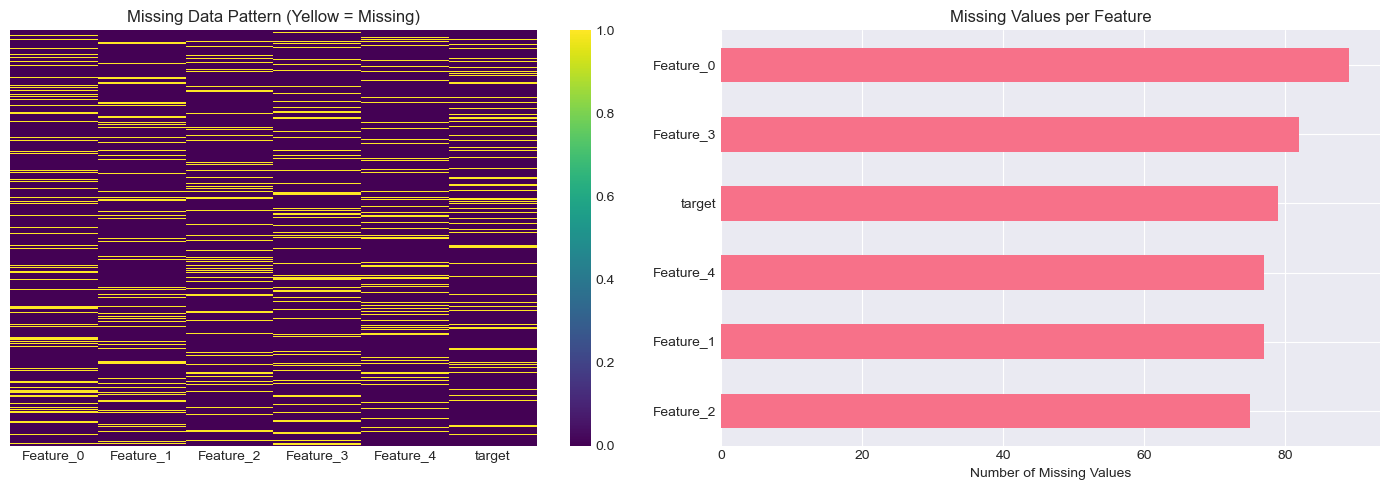

In [18]:
# Visualize missing data
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Heatmap of missing data
sns.heatmap(df_missing.isnull(), cbar = True, ax = axes[0], yticklabels = False, cmap = 'viridis')
axes[0].set_title('Missing Data Pattern (Yellow = Missing)')

# Missing value count
missing_counts = df_missing.isnull().sum()
missing_counts[missing_counts > 0].sort_values().plot(kind = 'barh', ax = axes[1])
axes[1].set_title('Missing Values per Feature')
axes[1].set_xlabel('Number of Missing Values')

plt.tight_layout()
plt.show()

In [23]:
# Create and apply KNN imputer
imputer = KNNImputer(n_neighbors = 5, weights = 'uniform')
imputer.set_output(transform = 'pandas')

# Imputed missing values
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_missing),
    columns = df_missing.columns
)

In [26]:
# Check if all missing values are filled
df_imputed.isnull().sum().sum()

np.int64(0)

In [28]:
# Compare original vs imputed data
feature_to_compare = 'Feature_0'
missing_indices = df_missing[feature_to_compare].isnull()

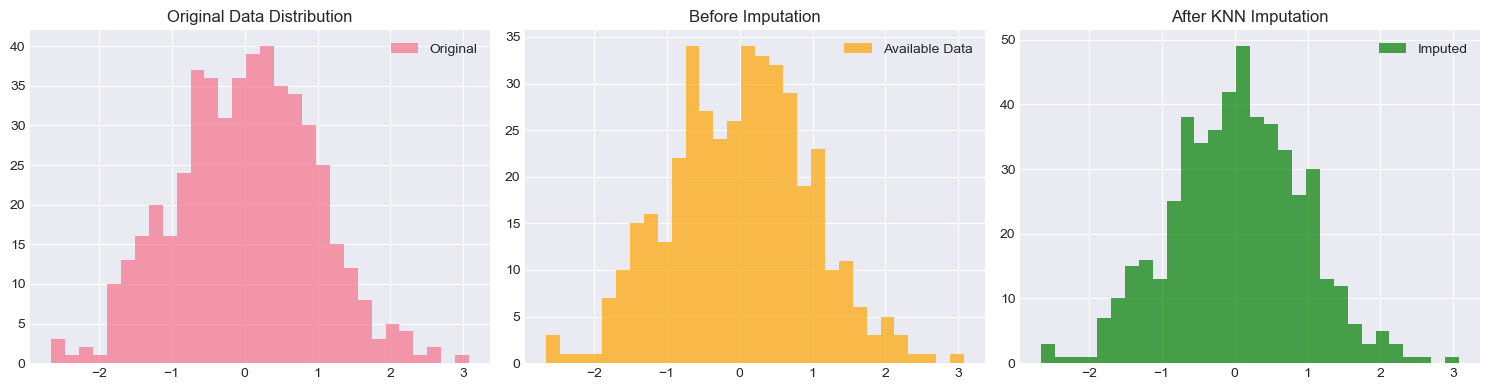


Original mean of Feature_0: 0.0124
Imputed mean of Feature_0: 0.0354
Difference: 0.0230


In [29]:
fig, axes = plt.subplots(1, 3, figsize = (15, 4))

# Original data
axes[0].hist(df[feature_to_compare], bins = 30, alpha = 0.7, label = 'Original')
axes[0].set_title("Original Data Distribution")
axes[0].legend()

# Before imputation 
data_before = df_missing[feature_to_compare].dropna()
axes[1].hist(data_before, bins = 30, alpha = 0.7, label = 'Available Data', color = 'orange')
axes[1].set_title('Before Imputation')
axes[1].legend()

# After imputation
axes[2].hist(df_imputed[feature_to_compare], bins = 30, alpha = 0.7, label = 'Imputed', color = 'green')
axes[2].set_title('After KNN Imputation')
axes[2].legend()

plt.tight_layout()
plt.show()


# Analyze imputation quality for known values
print(f"\nOriginal mean of Feature_0: {df[feature_to_compare].mean():.4f}")
print(f"Imputed mean of Feature_0: {df_imputed[feature_to_compare].mean():.4f}")
print(f"Difference: {abs(df[feature_to_compare].mean() - df_imputed[feature_to_compare].mean()):.4f}")


Imputation Method Comparison (Feature_0 RMSE):
                  RMSE
Median        0.950625
Mean          0.951123
Constant (0)  0.951372
KNN (k=5)     0.980553
KNN (k=10)    0.985941
KNN (k=3)     1.001921


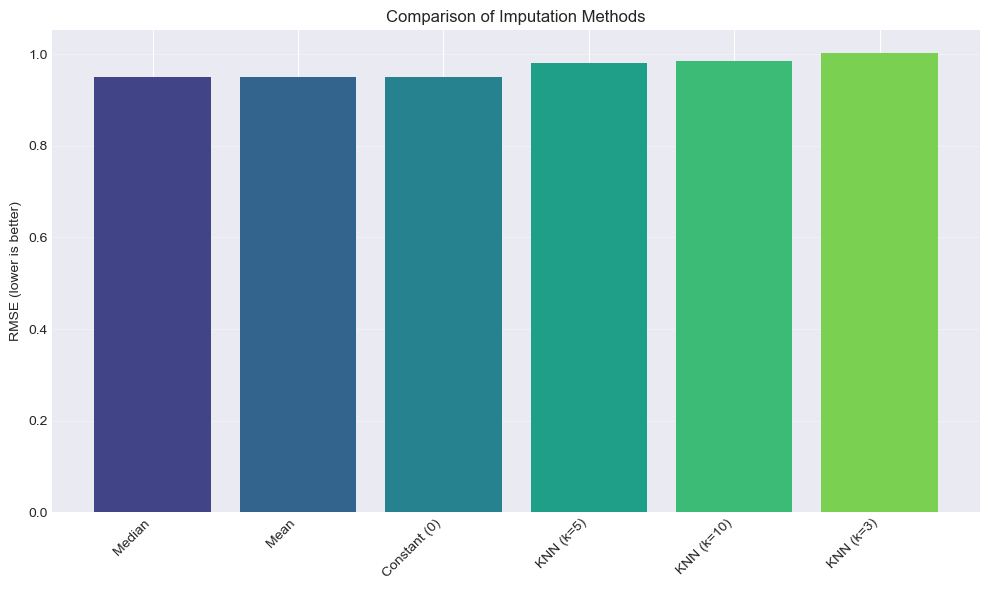

In [34]:
from sklearn.impute import SimpleImputer

# Create different imputers
imputers = {
    'KNN (k=3)': KNNImputer(n_neighbors=3),
    'KNN (k=5)': KNNImputer(n_neighbors=5),
    'KNN (k=10)': KNNImputer(n_neighbors=10),
    'Mean': SimpleImputer(strategy='mean'),
    'Median': SimpleImputer(strategy='median'),
    'Constant (0)': SimpleImputer(strategy='constant', fill_value=0)
}

results = {}

for name, imp in imputers.items():
    # Impute data
    X_imputed = imp.fit_transform(df_missing.drop('target', axis=1))
    df_imp = pd.DataFrame(X_imputed, columns=[col for col in df_missing.columns if col != 'target'])
    
    # Evaluate on Feature_0
    col = 'Feature_0'
    missing_idx = missing_mask[col]
    if missing_idx.sum() > 0:
        true_vals = df.loc[missing_idx, col]
        imp_vals = df_imp.loc[missing_idx, col]
        
        rmse = np.sqrt(mean_squared_error(true_vals, imp_vals))
        results[name] = rmse

# Compare results
comparison_df = pd.DataFrame.from_dict(results, orient='index', columns=['RMSE'])
comparison_df = comparison_df.sort_values('RMSE')

print("\nImputation Method Comparison (Feature_0 RMSE):")
print(comparison_df)

# Visualize comparison
plt.figure(figsize=(10, 6))
bars = plt.bar(comparison_df.index, comparison_df['RMSE'], 
               color=plt.cm.viridis(np.linspace(0.2, 0.8, len(comparison_df))))
plt.xticks(rotation=45, ha='right')
plt.ylabel('RMSE (lower is better)')
plt.title('Comparison of Imputation Methods')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

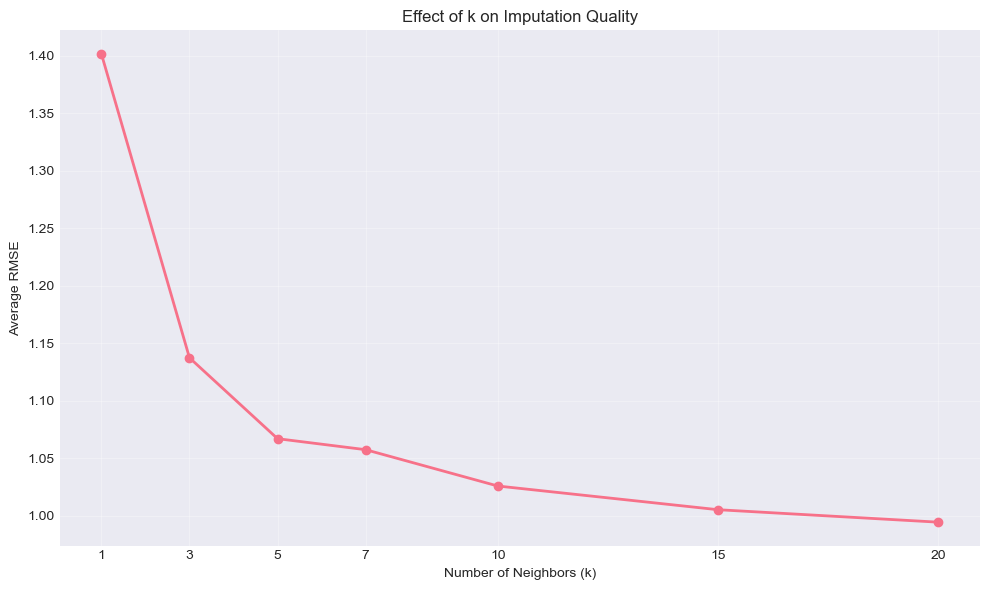

Best k value: 20


In [36]:
# Test different number of neighbors
k_values = [1, 3, 5, 7, 10, 15, 20]
knn_results = []

for k in k_values:
    imputer = KNNImputer(n_neighbors=k)
    X_imputed = imputer.fit_transform(df_missing.drop(columns ='target'))
    df_imp = pd.DataFrame(X_imputed, columns=[col for col in df_missing.columns if col != 'target'])
    
    # Calculate overall performance
    total_rmse = 0
    n_features = 0
    for col in df_imp.columns:
        missing_idx = missing_mask[col]
        if missing_idx.sum() > 0:
            true_vals = df.loc[missing_idx, col]
            imp_vals = df_imp.loc[missing_idx, col]
            rmse = np.sqrt(mean_squared_error(true_vals, imp_vals))
            total_rmse += rmse
            n_features += 1
    
    avg_rmse = total_rmse / n_features
    knn_results.append({'k': k, 'avg_rmse': avg_rmse})

knn_df = pd.DataFrame(knn_results)

# Visualize K effect
plt.figure(figsize=(10, 6))
plt.plot(knn_df['k'], knn_df['avg_rmse'], marker='o', linewidth=2)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Average RMSE')
plt.title('Effect of k on Imputation Quality')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

best_k = knn_df.loc[knn_df['avg_rmse'].idxmin(), 'k']
print(f"Best k value: {best_k}")

## Applied on a Real Dataset

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [38]:
df = pd.read_csv('train.csv', usecols = ['Age', 'Pclass', 'Fare', 'Survived'])
df.head()

,Survived,Pclass,Age,Fare
0,0,3,22.0,7.2500
1,1,1,38.0,71.2833
2,1,3,26.0,7.9250
3,1,1,35.0,53.1000
4,0,3,35.0,8.0500


In [45]:
print(f"Shape: {df.shape}")
print(f"Missing values per column:\n{df.isnull().sum()}")
print(f"Total missing values: {df.isnull().sum().sum()}")
print()
print(f"Missing percentages per column:\n{df.isnull().mean() * 100}")
print(f"Overall missing percentage: {df.isnull().sum().sum()/df.size * 100:.2f}%")

Shape: (891, 4)
Missing values per column:
Survived      0
Pclass        0
Age         177
Fare          0
dtype: int64
Total missing values: 177

Missing percentages per column:
Survived     0.00000
Pclass       0.00000
Age         19.86532
Fare         0.00000
dtype: float64
Overall missing percentage: 4.97%


In [44]:
X = df.drop(columns = ['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f"X train shape: {X_train.shape}")
print(f"X test shape: {X_test.shape}")
print()
print(f"y train shape: {y_train.shape}")
print(f"y test shape: {y_test.shape}")

X_train.head()

X train shape: (712, 3)
X test shape: (179, 3)

y train shape: (712,)
y test shape: (179,)


,Pclass,Age,Fare
331,1,45.5,28.5000
733,2,23.0,13.0000
382,3,32.0,7.9250
704,3,26.0,7.8542
813,3,6.0,31.2750


In [82]:
# Apply KNN Imputation
imputer = KNNImputer(n_neighbors = 3, weights = 'distance')
imputer.set_output(transform = 'pandas')

KNNImputer(n_neighbors=3, weights='distance')

In [83]:
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [84]:
lr = LogisticRegression()
lr.fit(X_train_imputed, y_train)

LogisticRegression()

In [85]:
y_pred = lr.predict(X_test_imputed)
print(f"Accuracy score: {accuracy_score(y_test, y_pred)}")

Accuracy score: 0.7374301675977654


In [97]:
si = SimpleImputer()
X_train_si = si.fit_transform(X_train)
X_test_si = si.transform(X_test)

lr = LogisticRegression()
lr.fit(X_train_si, y_train)
y_pred_si = lr.predict(X_test_si)
accuracy_score(y_test, y_pred_si)

0.7374301675977654

In [86]:
X = df.drop(columns = ['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f"X train shape: {X_train.shape}")
print(f"X test shape: {X_test.shape}")
print()
print(f"y train shape: {y_train.shape}")
print(f"y test shape: {y_test.shape}")

X_train.head()

X train shape: (712, 3)
X test shape: (179, 3)

y train shape: (712,)
y test shape: (179,)


,Pclass,Age,Fare
331,1,45.5,28.5000
733,2,23.0,13.0000
382,3,32.0,7.9250
704,3,26.0,7.8542
813,3,6.0,31.2750


In [87]:
X_train.isnull().sum()

Pclass      0
Age       140
Fare        0
dtype: int64

In [96]:
# Try different imputation approaches
imputers = {
    'KNN (k = 3)':KNNImputer(n_neighbors = 3, weights = 'uniform'),
    'KNN (k = 5)':KNNImputer(n_neighbors = 5, weights = 'uniform'),
    'KNN (k = 10)':KNNImputer(n_neighbors = 10, weights = 'uniform'),
    'Mean': SimpleImputer(strategy = 'mean'),
    'Median': SimpleImputer(strategy = 'median'),
    'Constant': SimpleImputer(strategy = 'constant', fill_value = 0)
}

for name, imp in imputers.items():
    X_train_imputed = imp.fit_transform(X_train)
    X_test_imputed = imp.transform(X_test)

    model = LogisticRegression()
    model.fit(X_train_imputed, y_train)
    y_pred = model.predict(X_test_imputed)

    print(f"Accuracy score for {name} imputation: {accuracy_score(y_test, y_pred):.2f}")
    print("-"* 60)

Accuracy score for KNN (k = 3) imputation: 0.74
------------------------------------------------------------
Accuracy score for KNN (k = 5) imputation: 0.74
------------------------------------------------------------
Accuracy score for KNN (k = 10) imputation: 0.75
------------------------------------------------------------
Accuracy score for Mean imputation: 0.74
------------------------------------------------------------
Accuracy score for Median imputation: 0.74
------------------------------------------------------------
Accuracy score for Constant imputation: 0.72
------------------------------------------------------------


In [116]:
# Apply GridSearchCV with pipeline
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps = [
    ('imputer', KNNImputer()),
    ('scaler', StandardScaler()),
    ('regressor', LogisticRegression())
])

# Define parameter grid
param_grid = {
    'imputer__n_neighbors':[3, 5, 7, 10],
    'imputer__weights':['uniform', 'distance'],
    'imputer__metric':['nan_euclidean']
}

X = df.drop(columns = ['Survived'])
y = df.Survived

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [118]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv = 10,
    scoring = 'accuracy',
    n_jobs = -1,
    verbose = 1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_}")

Fitting 10 folds for each of 8 candidates, totalling 80 fits
Best parameters: {'imputer__metric': 'nan_euclidean', 'imputer__n_neighbors': 3, 'imputer__weights': 'uniform'}
Best CV score: 0.6966549295774648


In [120]:
grid_search.best_estimator_

Pipeline(steps=[('imputer', KNNImputer(n_neighbors=3)),
                ('scaler', StandardScaler()),
                ('regressor', LogisticRegression())])

In [122]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Generate predictions using the best pipeline found by GridSearchCV
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# 2. Calculate the proper classification metrics
test_accuracy = accuracy_score(y_test, y_pred)

print(f"✅ Test Accuracy Score: {test_accuracy:.4f}")
print("-" * 60)
print("📊 DETAILED CLASSIFICATION REPORT:")
print("-" * 60)
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))


✅ Test Accuracy Score: 0.7430
------------------------------------------------------------
📊 DETAILED CLASSIFICATION REPORT:
------------------------------------------------------------
              precision    recall  f1-score   support

        Died       0.73      0.89      0.80       105
    Survived       0.77      0.54      0.63        74

    accuracy                           0.74       179
   macro avg       0.75      0.71      0.72       179
weighted avg       0.75      0.74      0.73       179

